# Table of Content

- Multivariate Analysis
  - Lmplot
  - Boxplot
  - Pairplot
  - Facetgrid
  - Plotly

####  Import required libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

#### Load the dataset

In [ ]:
#df = pd.read_csv('honeyproduction.csv')
#df.head()

In [32]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/honeyproduction.csv')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,state,numcol,yieldpercol,totalprod,stocks,priceperlb,prodvalue,year
0,AL,16000.0,71,1136000.0,159000.0,0.72,818000.0,1998
1,AZ,55000.0,60,3300000.0,1485000.0,0.64,2112000.0,1998
2,AR,53000.0,65,3445000.0,1688000.0,0.59,2033000.0,1998
3,CA,450000.0,83,37350000.0,12326000.0,0.62,23157000.0,1998
4,CO,27000.0,72,1944000.0,1594000.0,0.70,1361000.0,1998


## 1. Multivariate Analysis 
### 1.1 Lmplot

Lets visualize the relationship between 'number of colonies' and 'production value' at different year through Lmplot

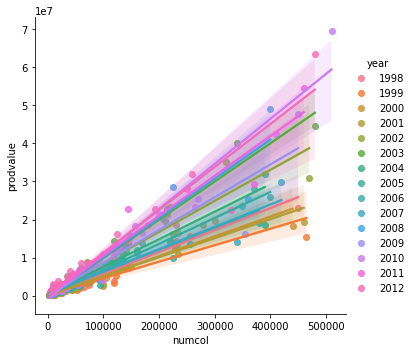

In [28]:
sns.lmplot('numcol','prodvalue',data=df,hue='year')
plt.show()

- We can observe from the above plot that there is an significant increase in the production value as the number of colonies increases throughout the different years

-------------

### 1.2 Boxplot

for simplification we are grouping the values of columns 'yieldpercol' and 'year' into some groups and then using the created groups(columns) for plotting a boxplot

In [33]:
## creating a new column yieldpercol_group by grouping the values of yieldpercol
df["yieldpercol_group"] = pd.cut(df.yieldpercol, [30,50,70,90,100,130])

## creating a new column year_group by grouping the values of year
df['year_group'] = pd.cut(df.year,[1998,2005,2012])

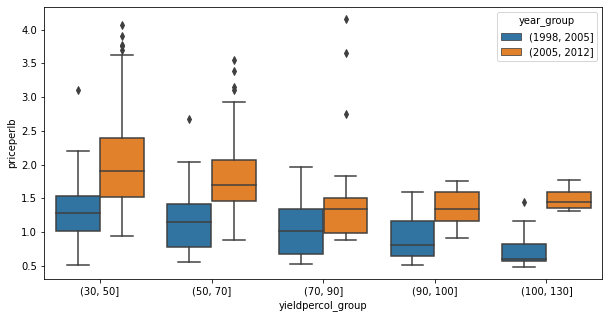

In [39]:
## using the 
plt.figure(figsize=(10,5))
sns.boxplot(df['yieldpercol_group'],df['priceperlb'],hue='year_group',data=df)
plt.show()

- We can observe from the above plot, that the priceperlb value is higher when the yieldpercolonies is lesser.
- Similarly we can observe that there is a decrease in the priceperlb values when there is increase in the yieldpercol.
- And, also the price is lesser for the year_group 1998-2005 and the price is comparitively higher for the year_group 2005-2012

### 1.3 Pairplot

Let us visualize and understand the relationship between the multiple pairs of variables throughout diffferent years using pairplot

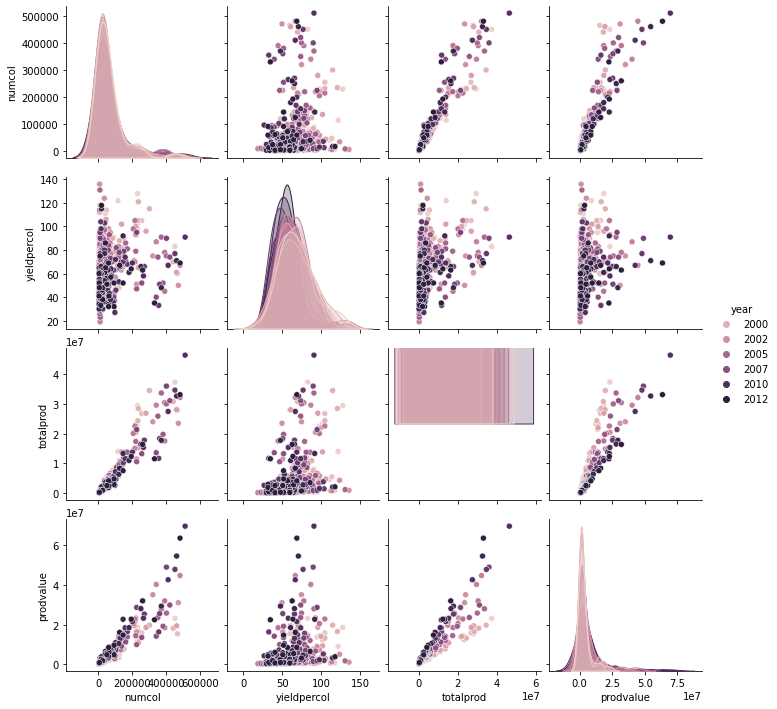

In [ ]:
df_pairplot = df[['numcol', 'yieldpercol', 'totalprod', 'prodvalue','year']]
sns.pairplot(df_pairplot,hue='year')
plt.show()

- We can observe that there is a linear relationship between the columns totalprod & prodvalue, there is a significant increase in production value as the total production increases.
- We can observe a linear relationship between the columns numcol & produvalue, there is a significant increase in production value as the number of colonies increases.
-------------

### 1.4 FacetGrid

We can compare the distribution of the production value across different years by using multiplot grid - FacetGrid

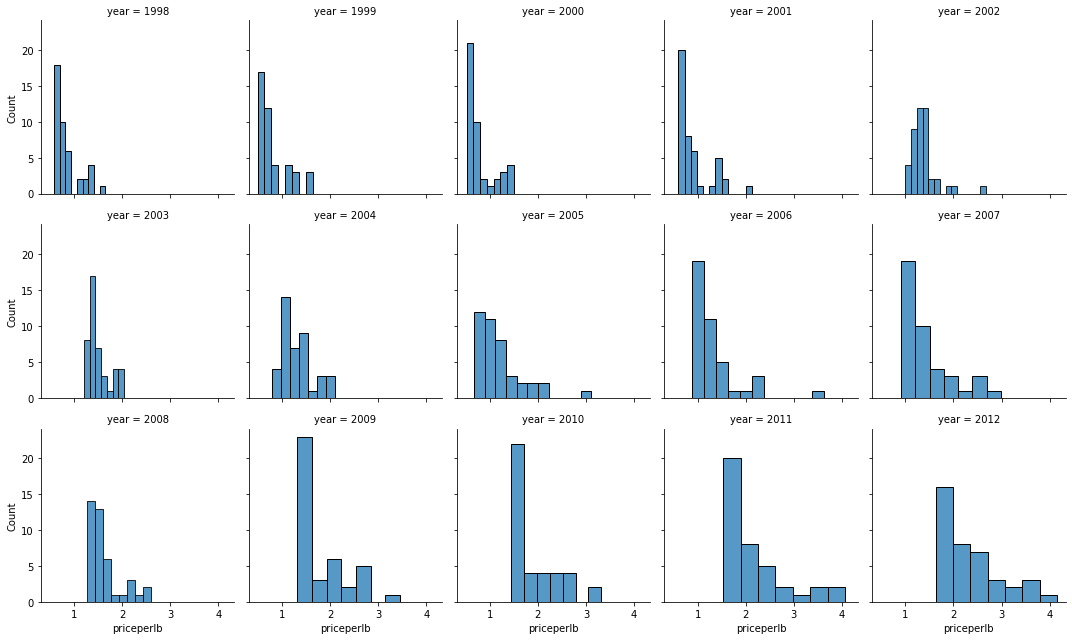

In [9]:
ax = sns.FacetGrid(df,col='year', col_wrap=5)
ax.map_dataframe(sns.histplot, x='priceperlb')
plt.show()

- As we can observe from above multiple histplots for distribution of the 'priceperlb' across different years
- At the initial years(1998-2007) the distribution of 'priceperlb' range is lesser
- Later on the priceperlb got expensive and the distribution is comparitvely very different from the initial years

### 1.5 Plotly

In [40]:
import plotly.express as px

In [48]:
import plotly.express as px
fig = px.scatter(x=df['numcol'], y=df['prodvalue'], color=df['state'], animation_frame=df['year'])
fig.show()

--------------
## Happy Learning :)
--------------